In [1]:
import pandas as pd

In [3]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import pickle

import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/tdsurv/lib')

from tdsurv.utils import kaplan_meier

In [4]:
def safe_binary(true_, false_):
    def f(x):
        if x in (true_, false_):
            return x == true_
        else:
            raise ValueError(f"value '{x}' not in '{true_}', '{false_}'")
    return f

cols = (
    # Patient's identifier; in total there are 467 patients.
    ("patient", int),
    # The time to death or censoring.
    ("Time", float),
    # ?
    ("death", safe_binary("1", "0")),
    # The CD4 cells count.
    ("CD4", float),
    # The time point (in month) at which the CD4 cells count was recorded.
    ("obstime", int),
    # A factor with levels `ddC` denoting zalcitabine and `ddI` denoting didanosine.
    ("drug", safe_binary("ddC", "ddI")),
    # A factor with levels `female` and `male`.
    ("gender", safe_binary("female", "male")),
    # A factor with levels
    # - `AIDS` denoting previous opportunistic infection (AIDS diagnosis) at study entry,
    # - `noAIDS` denoting no previous infection.
    ("prevOI", safe_binary("AIDS", "noAIDS")),
    # A factor with levels
    # - `intolerance` denoting AZT intolerance,
    # - `failure` denoting AZT failure.
    ("AZT", safe_binary("intolerance", "failure")),
    # Start of observation interval.
    ("start", float),
    # End of observation interval.
    ("stop", float),
    # Indicator variable of event at end of observation interval.
    ("event", safe_binary("1", "0")),
)

names, funcs = zip(*cols)

In [33]:
data = list()
path_syn = "/Users/mariana/Downloads/aids_syn/aids.csv"
path_o = "/Users/mariana/Documents/projects/Huawei/tdsurv/data/aids.csv"
with open(path_o) as f:
    reader = csv.reader(f)
    cols = next(reader)
    for row in reader:
        data.append([f(elem) for elem, f in zip(row[1:], funcs)])

df_o = pd.DataFrame(data, columns=names)
print("Number of observations: {:,}".format(len(df)))

Number of observations: 1,405


In [34]:
data = list()
path_syn = "/Users/mariana/Downloads/aids_syn/aids.csv"
path_o = "/Users/mariana/Documents/projects/Huawei/tdsurv/data/aids.csv"
with open(path_syn) as f:
    reader = csv.reader(f)
    cols = next(reader)
    for row in reader:
        data.append([f(elem) for elem, f in zip(row, funcs)])

df_syn = pd.DataFrame(data, columns=names)
print("Number of observations: {:,}".format(len(df)))

Number of observations: 1,405


In [35]:
df_syn.CD4.mean()

7.522598135516015

In [37]:
df_o.CD4.mean()

7.022919148214661

Number of patients / sequences: 430


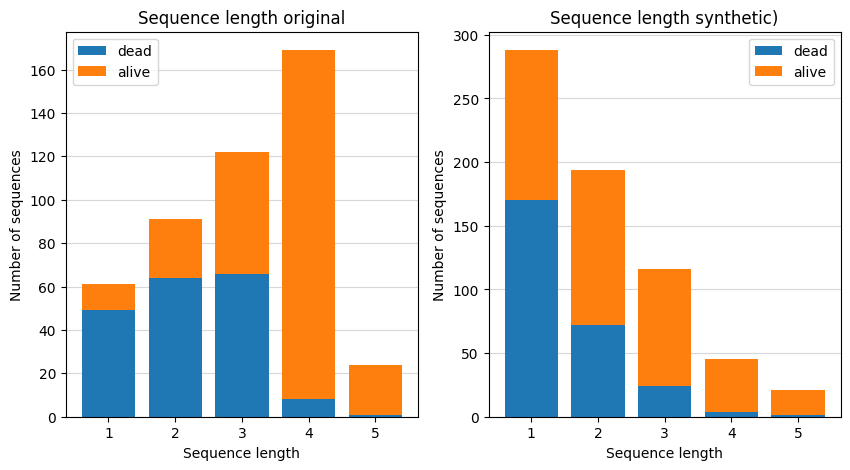

In [41]:


print("Number of patients / sequences: {:,}".format(len(agg)))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

cumul = np.zeros(len(bins))
ax = axs[0]
df = df_o

agg = df.groupby("patient")["obstime"]
bins = np.arange(1, 6)

for dead in (True, False):
    vals = df[df.death == dead].groupby("patient")["obstime"].count().values
    cnts, _ = np.histogram(vals, bins=np.arange(1, 7))
    ax.bar(bins, cnts, bottom=cumul, label="dead" if dead else "alive")
    cumul += cnts

ax.set_xticks(bins)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Sequence length original")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Number of sequences")
ax.legend()

cumul = np.zeros(len(bins))
ax = axs[1]
df = df_syn

agg = df.groupby("patient")["obstime"]
bins = np.arange(1, 6)

for dead in (True, False):
    vals = df[df.death == dead].groupby("patient")["obstime"].count().values
    cnts, _ = np.histogram(vals, bins=np.arange(1, 7))
    ax.bar(bins, cnts, bottom=cumul, label="dead" if dead else "alive")
    cumul += cnts

ax.set_xticks(bins)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Sequence length synthetic)")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Number of sequences")
ax.legend()

In [76]:
df = df_o

agg = df.groupby("patient")["obstime"]
bins = np.arange(1, 6)

vals = df[df.death == dead].groupby("patient")["obstime"].count().values
cnts, _ = np.histogram(vals, bins=np.arange(1, 7))

first = list()
second = list()
tail = list()
for seq in agg.apply(list).values:
    deltas = np.diff(seq)
    first.extend(deltas[0:1])
    second.extend(deltas[1:2])
    tail.extend(deltas[2:])

In [77]:
print(pd.unique(df_o.obstime))
print(pd.unique(df_syn.obstime))

[ 0  6 12 18  2]
[18  0  6  2 12]


In [80]:
agg.apply(list).values[1]

[0, 6, 12, 18]

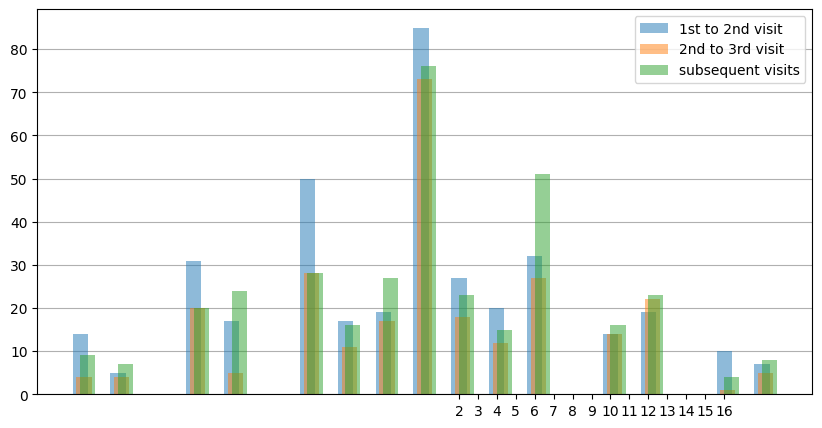

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))

vals, cnts = np.unique(first, return_counts=True)
ax.bar(vals, cnts, alpha=0.5, label="1st to 2nd visit")

vals, cnts = np.unique(second, return_counts=True)
ax.bar(vals+0.2, cnts, alpha=0.5, label="2nd to 3rd visit")

vals, cnts = np.unique(tail, return_counts=True)
ax.bar(vals+0.4, cnts, alpha=0.5, label="subsequent visits")

ax.set_xticks(np.arange(2, 17))
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend()